# Day 19 - Transformer - 彻底抛弃 RNN

> 目标: 理解 Transformer 如何只用 Attention 处理序列, 不要 RNN
>
> 核心: Self-Attention + Multi-Head + 位置编码 = 并行计算 + 全局视野

---

## RNN vs Transformer

```
RNN:                                     Transformer:
  顺序计算, 无法并行                         所有位置同时算
  梯度消失, 远程依赖弱                        Attention 直连, 远程没问题
  信息瓶颈 (Seq2Seq)                        无瓶颈

     x1 -> x2 -> x3 -> ... -> xT          x1  x2  x3  ...  xT
      |     |     |            |           |   |   |        |
      v     v     v            v           v   v   v        v
     h1 -> h2 -> h3 -> ... -> hT          Attention 同时计算!
     顺序依赖, 第 t 步必须等 t-1           所有位置一步到位
```

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

print('=' * 40)
print('Day 19 - Transformer')
print('=' * 40)

Day 19 - Transformer


## 1. Self-Attention (自注意力)

> 序列中的每个位置都跟所有位置计算关联
>
> 跟 Day 18 的 Attention 区别:
>   - Day 18: 解码器(Q) 看 编码器(K,V)  ← 交叉注意力
>   - Day 19: Q = K = V = 同一个序列     ← 自注意力

### Scaled Dot-Product Attention 公式

```
输入: X (seq_len, d_model)

Step 1: 线性变换得到 Q, K, V
  Q = X @ W_q     查询: "我想找什么"
  K = X @ W_k     键:   "我有什么"
  V = X @ W_v     值:   "我给什么"

Step 2: 计算注意力分数
  scores = Q @ K^T / sqrt(d_k)    ← 除以 sqrt(d_k) 防止梯度消失
  
Step 3: softmax 归一化
  attention = softmax(scores, dim=-1)

Step 4: 加权求和
  output = attention @ V

直观理解:
  "我爱你" 中的 "爱":
    Q(爱) 问: "我跟谁关系近?"
    K(我) 答: "0.3"
    K(爱) 答: "0.4"
    K(你) 答: "0.3"
    最后 V 按权重融合 → 输出包含上下文信息的"爱"
```

In [2]:
# ============================================
# 手写 Self-Attention
# ============================================

class SelfAttention(nn.Module):
    """Scaled Dot-Product Self-Attention"""
    def __init__(self, d_model, d_k=None):
        super().__init__()
        self.d_k = d_k if d_k else d_model
        self.W_q = nn.Linear(d_model, self.d_k, bias=False)
        self.W_k = nn.Linear(d_model, self.d_k, bias=False)
        self.W_v = nn.Linear(d_model, self.d_k, bias=False)

    def forward(self, x):
        """
        x: (batch, seq_len, d_model)
        返回:
          output:    (batch, seq_len, d_k)  注意力输出
          attn:      (batch, seq_len, seq_len)  注意力权重
        """
        Q = self.W_q(x)                         # (batch, seq, d_k)
        K = self.W_k(x)                         # (batch, seq, d_k)
        V = self.W_v(x)                         # (batch, seq, d_k)

        scores = torch.matmul(Q, K.transpose(-2, -1))  # (batch, seq, seq)
        scores = scores / np.sqrt(self.d_k)     # 缩放!

        attn = F.softmax(scores, dim=-1)        # (batch, seq, seq)
        output = torch.matmul(attn, V)          # (batch, seq, d_k)

        return output, attn


# 测试 Self-Attention
batch, seq_len, d_model = 2, 6, 16
x = torch.randn(batch, seq_len, d_model)

sa = SelfAttention(d_model, d_k=16)
out, attn = sa(x)

print(f'输入形状:           {tuple(x.shape)}')
print(f'Self-Attention 输出: {tuple(out.shape)}')
print(f'Attention 权重矩阵:  {tuple(attn.shape)}')
print(f'注意力行和 (应=1):    {attn[0, 0].sum().item():.4f}')
print(f'参数数量:            {sum(p.numel() for p in sa.parameters()):,}')

输入形状:           (2, 6, 16)
Self-Attention 输出: (2, 6, 16)
Attention 权重矩阵:  (2, 6, 6)
注意力行和 (应=1):    1.0000
参数数量:            768


## 2. Self-Attention 可视化

> 看一个句子里每个词跟其他词的注意力权重

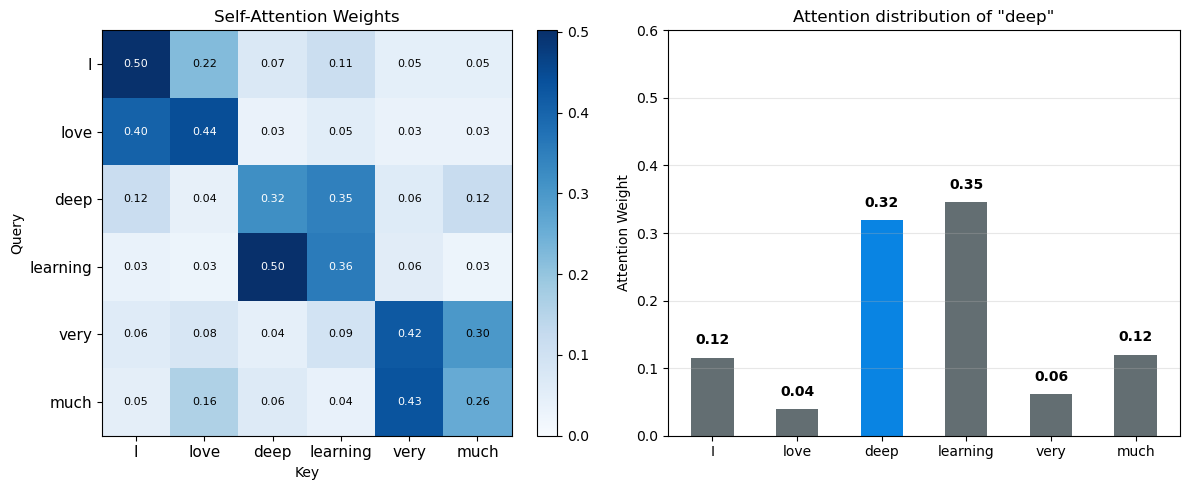

In [3]:
# ============================================
# Self-Attention 权重可视化
# ============================================

sentence = ['I', 'love', 'deep', 'learning', 'very', 'much']
n_tokens = len(sentence)

# 模拟一个训练好的 Self-Attention 权重
# 每个词跟自己关系最密切 (对角线最高), 同时跟语义相关的词也很高
np.random.seed(42)
raw = np.random.randn(n_tokens, n_tokens) * 0.5
# 增强对角线 (自己跟自己)
for i in range(n_tokens):
    raw[i, i] += 2.0
# 增强语义关联: love-I, deep-learning, very-much
raw[1, 0] += 1.5; raw[0, 1] += 1.5   # love <-> I
raw[3, 2] += 1.5; raw[2, 3] += 1.5   # learning <-> deep
raw[5, 4] += 1.5; raw[4, 5] += 1.5   # much <-> very
# softmax
attn_viz = np.exp(raw) / np.exp(raw).sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 热力图
ax = axes[0]
im = ax.imshow(attn_viz, cmap='Blues', aspect='auto', vmin=0, vmax=attn_viz.max())
ax.set_xticks(range(n_tokens))
ax.set_yticks(range(n_tokens))
ax.set_xticklabels(sentence, fontsize=11)
ax.set_yticklabels(sentence, fontsize=11)
ax.set_xlabel('Key')
ax.set_ylabel('Query')
ax.set_title('Self-Attention Weights')
plt.colorbar(im, ax=ax)
for i in range(n_tokens):
    for j in range(n_tokens):
        v = attn_viz[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                fontsize=8, color='white' if v > 0.3 else 'black')

# "deep" 这个词的注意力分布
ax = axes[1]
idx_deep = 2
colors = ['#636e72' if i != idx_deep else '#0984e3' for i in range(n_tokens)]
bars = ax.bar(sentence, attn_viz[idx_deep], color=colors, width=0.5)
ax.set_ylim(0, 0.6)
ax.set_ylabel('Attention Weight')
ax.set_title('Attention distribution of "deep"')
ax.grid(alpha=0.3, axis='y')
for bar, v in zip(bars, attn_viz[idx_deep]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.02,
            f'{v:.2f}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('day19_self_attention.png', dpi=150)
plt.show()

## 3. Multi-Head Attention (多头注意力)

> 一组 Attention 只能学到一种关系, 多头可以学到多种关系

```
单头: 只关注"语法关系"
多头:
  Head 1: 关注"主语-动词"关系
  Head 2: 关注"形容词-名词"关系
  Head 3: 关注"距离远近"
  Head 4: 关注"指代关系" (it -> cat)
  ...

实现:
  1. 把 d_model 分成 h 个头, 每个头 d_k = d_model / h
  2. h 个头并行算 Attention
  3. 拼起来再过一层线性

  d_model = 512, h = 8 -> 每个头 d_k = 64
  参数量不变, 但学到 8 种不同的关系!
```

In [4]:
# ============================================
# Multi-Head Self-Attention
# ============================================

class MultiHeadSelfAttention(nn.Module):
    """多头自注意力"""
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, 'd_model 必须能被 num_heads 整除'
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x):
        batch, seq_len, _ = x.shape

        # 线性变换 + 拆头
        Q = self.W_q(x).view(batch, seq_len, self.num_heads, self.d_k)
        K = self.W_k(x).view(batch, seq_len, self.num_heads, self.d_k)
        V = self.W_v(x).view(batch, seq_len, self.num_heads, self.d_k)

        # (batch, num_heads, seq, d_k)  -> 每个头独立算 Attention
        Q = Q.transpose(1, 2)
        K = K.transpose(1, 2)
        V = V.transpose(1, 2)

        # Scaled Dot-Product
        scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(self.d_k)
        attn = F.softmax(scores, dim=-1)
        context = torch.matmul(attn, V)  # (batch, num_heads, seq, d_k)

        # 合并头
        context = context.transpose(1, 2).contiguous()
        context = context.view(batch, seq_len, self.d_model)

        output = self.W_o(context)  # 输出投影
        return output, attn


# 测试 Multi-Head
batch, seq_len, d_model, num_heads = 2, 6, 16, 4
mha = MultiHeadSelfAttention(d_model, num_heads)
x = torch.randn(batch, seq_len, d_model)
out, attn = mha(x)

print(f'd_model={d_model}, heads={num_heads}, d_k={d_model // num_heads}')
print(f'输入:               {tuple(x.shape)}')
print(f'多头输出:            {tuple(out.shape)}')
print(f'Attention 形状:      {tuple(attn.shape)}  (batch, heads, seq, seq)')
print(f'参数量:              {sum(p.numel() for p in mha.parameters()):,}')

d_model=16, heads=4, d_k=4
输入:               (2, 6, 16)
多头输出:            (2, 6, 16)
Attention 形状:      (2, 4, 6, 6)  (batch, heads, seq, seq)
参数量:              1,024


## 4. 位置编码 (Positional Encoding)

> Self-Attention 没有顺序概念! "我爱你" 和 "你爱我" 对它来说一样
>
> 位置编码 = 告诉模型词的位置信息

### 公式

```
PE(pos, 2i)   = sin(pos / 10000^{2i/d_model})
PE(pos, 2i+1) = cos(pos / 10000^{2i/d_model})

为什么用 sin/cos?
  1. 有界 (-1~1), 稳定
  2. 每个位置编码唯一
  3. 可以外推到比训练更长的序列
  4. 不同频率 -> 不同粒度的位置信息
```

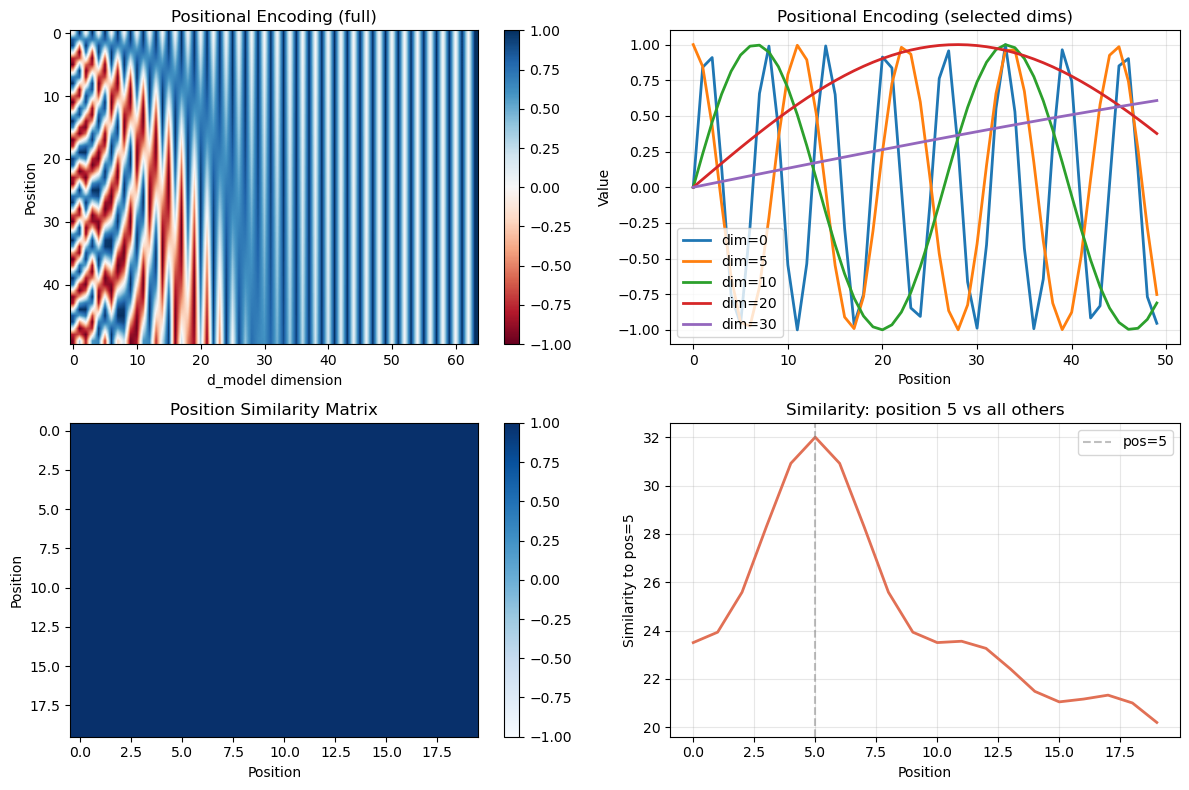

关键观察:
  - 不同维度有不同频率 (低频=粗粒度, 高频=细粒度)
  - 位置越近, 编码向量越相似 (对角线亮)
  - 对称结构: 前向和后向距离相近


In [5]:
# ============================================
# 位置编码实现 & 可视化
# ============================================

class PositionalEncoding(nn.Module):
    """Sinusoidal 位置编码"""
    def __init__(self, d_model, max_len=100):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() *
                            -(np.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        return x + self.pe[:, :x.size(1), :]


pe = PositionalEncoding(d_model=64, max_len=50)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 位置编码热力图
ax = axes[0, 0]
im = ax.imshow(pe.pe[0].numpy(), cmap='RdBu', aspect='auto',
               interpolation='bilinear', vmin=-1, vmax=1)
ax.set_xlabel('d_model dimension')
ax.set_ylabel('Position')
ax.set_title('Positional Encoding (full)')
plt.colorbar(im, ax=ax)

# 特定维度的编码值
ax = axes[0, 1]
dims_to_plot = [0, 5, 10, 20, 30]
for d in dims_to_plot:
    ax.plot(pe.pe[0, :, d].numpy(), label=f'dim={d}', lw=2)
ax.set_xlabel('Position')
ax.set_ylabel('Value')
ax.set_title('Positional Encoding (selected dims)')
ax.legend(); ax.grid(alpha=0.3)

# 每个位置的编码向量相似度 (位置越近越相似)
ax = axes[1, 0]
pe_vecs = pe.pe[0, :20].numpy()
sim = pe_vecs @ pe_vecs.T
im = ax.imshow(sim, cmap='Blues', aspect='auto', vmin=-1, vmax=1)
ax.set_xlabel('Position'); ax.set_ylabel('Position')
ax.set_title('Position Similarity Matrix')
plt.colorbar(im, ax=ax)

# 位置 5 跟其他位置的相似度
ax = axes[1, 1]
pos = 5
ax.plot(sim[pos], lw=2, color='#e17055')
ax.axvline(x=pos, ls='--', color='gray', alpha=0.5, label=f'pos={pos}')
ax.set_xlabel('Position'); ax.set_ylabel('Similarity to pos=5')
ax.set_title('Similarity: position 5 vs all others')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('day19_positional_encoding.png', dpi=150)
plt.show()

print('关键观察:')
print('  - 不同维度有不同频率 (低频=粗粒度, 高频=细粒度)')
print('  - 位置越近, 编码向量越相似 (对角线亮)')
print('  - 对称结构: 前向和后向距离相近')

## 5. Transformer Encoder Block (完整)

> 把上面所有组件拼起来:
>
```
输入
  v
位置编码
  v
Multi-Head Self-Attention
  v
Add & LayerNorm  (残差连接 + 层归一化)
  v
Feed Forward (两层 MLP: linear -> ReLU -> linear)
  v
Add & LayerNorm
  v
输出

注意: 每个子层都有残差连接! (跟 ResNet 一样解决退化)
```

In [6]:
# ============================================
# 完整的 Transformer Encoder 层
# ============================================

class TransformerEncoderLayer(nn.Module):
    """一个 Transformer Encoder Block"""
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attention = MultiHeadSelfAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model),
        )
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x):
        # 子层 1: Multi-Head Self-Attention + 残差
        attn_out, _ = self.attention(x)
        x = self.norm1(x + self.dropout1(attn_out))  # 残差连接!

        # 子层 2: Feed Forward + 残差
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout2(ffn_out))   # 残差连接!

        return x


class TransformerEncoder(nn.Module):
    """堆叠多个 Encoder 层 + 位置编码"""
    def __init__(self, vocab_size, d_model, num_heads, d_ff,
                 num_layers, max_len, dropout=0.1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len)
        self.layers = nn.ModuleList([
            TransformerEncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (batch, seq_len)
        x = self.dropout(self.pos_enc(self.embed(x)))
        for layer in self.layers:
            x = layer(x)
        return x


vocab_size, d_model, num_heads, d_ff, num_layers, max_len = 30, 32, 4, 64, 2, 20
enc = TransformerEncoder(vocab_size, d_model, num_heads, d_ff, num_layers, max_len)
x = torch.randint(0, vocab_size, (4, 10))
out = enc(x)

print(f'输入形状:           {tuple(x.shape)}  (batch=4, seq=10)')
print(f'输出形状:           {tuple(out.shape)}  (batch, seq, d_model={d_model})')
print(f'Encoder 参数量:     {sum(p.numel() for p in enc.parameters()):,}')

输入形状:           (4, 10)  (batch=4, seq=10)
输出形状:           (4, 10, 32)  (batch, seq, d_model=32)
Encoder 参数量:     17,792


## 6. 实战: Transformer 文本分类

> 用 Transformer Encoder 做文本分类 (跟 Day 10 的 MLP 分类对比)
>
> 任务: 随机生成的 "正样本" / "负样本" 文本分类

In [9]:
# ============================================
# 准备数据: 随机生成分类数据
# ============================================

vocab_size = 20
seq_len = 8
num_samples = 500

np.random.seed(42)

# 正样本: 包含特定模式 (词 5, 7, 9 出现较多)
X_pos = np.random.randint(0, vocab_size, (num_samples // 2, seq_len))
for i in range(len(X_pos)):
    X_pos[i, 2:5] = np.random.choice([5, 7, 9], 3)  # 正样本模式

# 负样本: 随机
X_neg = np.random.randint(0, vocab_size, (num_samples // 2, seq_len))

X = np.concatenate([X_pos, X_neg], axis=0)
y = np.array([1] * len(X_pos) + [0] * len(X_neg))

# shuffle
idx = np.random.permutation(num_samples)
X, y = X[idx], y[idx]

split = int(0.8 * len(X))
X_train = torch.LongTensor(X[:split])
y_train = torch.LongTensor(y[:split])
X_test  = torch.LongTensor(X[split:])
y_test  = torch.LongTensor(y[split:])

print(f'训练集: {len(X_train)} 样本')
print(f'测试集: {len(X_test)} 样本')
print(f'正样本 = 包含词 5/7/9 的序列')

训练集: 400 样本
测试集: 100 样本
正样本 = 包含词 5/7/9 的序列


In [10]:
# ============================================
# Transformer 分类器
# ============================================

class TransformerClassifier(nn.Module):
    """Transformer Encoder + 分类头"""
    def __init__(self, vocab_size, d_model=32, num_heads=4,
                 d_ff=64, num_layers=2, max_len=20, num_classes=2):
        super().__init__()
        self.encoder = TransformerEncoder(
            vocab_size, d_model, num_heads, d_ff, num_layers, max_len
        )
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x):
        # 取所有位置的均值 (全局池化) 再做分类
        enc_out = self.encoder(x)  # (batch, seq, d_model)
        pooled = enc_out.mean(dim=1)  # (batch, d_model)
        return self.classifier(pooled)


model_tf = TransformerClassifier(vocab_size)
print(f'Transformer 分类器参数量: {sum(p.numel() for p in model_tf.parameters()):,}')
print(model_tf)

Transformer 分类器参数量: 17,538
TransformerClassifier(
  (encoder): TransformerEncoder(
    (embed): Embedding(20, 32)
    (pos_enc): PositionalEncoding()
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (attention): MultiHeadSelfAttention(
          (W_q): Linear(in_features=32, out_features=32, bias=False)
          (W_k): Linear(in_features=32, out_features=32, bias=False)
          (W_v): Linear(in_features=32, out_features=32, bias=False)
          (W_o): Linear(in_features=32, out_features=32, bias=False)
        )
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (ffn): Sequential(
          (0): Linear(in_features=32, out_features=64, bias=True)
          (1): ReLU()
          (2): Linear(in_features=64, out_features=32, bias=True)
        )
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout2): Dropout(p=0.1, inplace=False

Epoch  5/30 | Loss = 0.1391 | Test Acc = 0.9400
Epoch 10/30 | Loss = 0.0595 | Test Acc = 0.9600
Epoch 15/30 | Loss = 0.0533 | Test Acc = 0.9600
Epoch 20/30 | Loss = 0.0298 | Test Acc = 0.9700
Epoch 25/30 | Loss = 0.0519 | Test Acc = 0.9500
Epoch 30/30 | Loss = 0.0099 | Test Acc = 0.9600


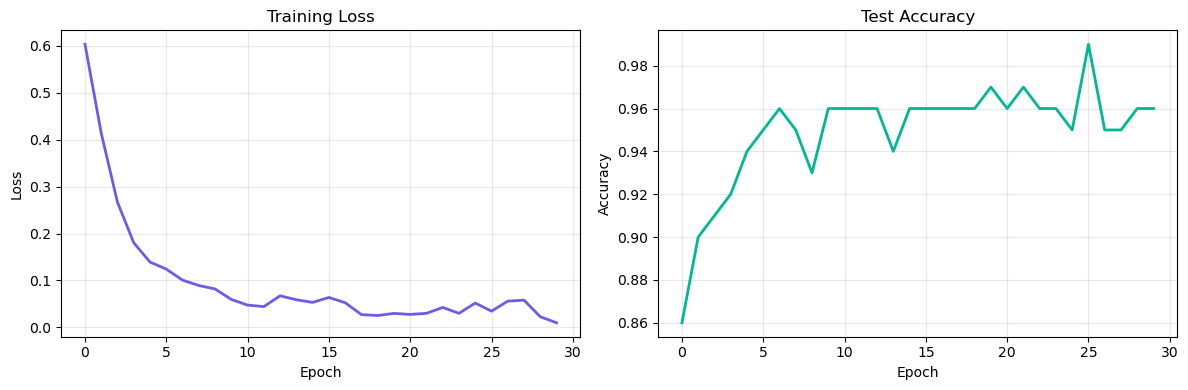


最终测试准确率: 0.9600 (96.0%)


In [11]:
# ============================================
# 训练 & 测试
# ============================================

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_tf.parameters(), lr=0.001)

n_epochs = 30
batch_size = 32
n_batches = len(X_train) // batch_size
train_losses, test_accs = [], []

for epoch in range(n_epochs):
    # 训练
    model_tf.train()
    eloss = 0
    perm = torch.randperm(len(X_train))
    for i in range(n_batches):
        idx = perm[i*batch_size:(i+1)*batch_size]
        optimizer.zero_grad()
        loss = criterion(model_tf(X_train[idx]), y_train[idx])
        loss.backward()
        optimizer.step()
        eloss += loss.item()
    train_losses.append(eloss / n_batches)

    # 测试
    model_tf.eval()
    with torch.no_grad():
        preds = model_tf(X_test).argmax(dim=1)
        acc = (preds == y_test).float().mean().item()
        test_accs.append(acc)

    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1:>2d}/{n_epochs} | Loss = {train_losses[-1]:.4f} | Test Acc = {acc:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_losses, lw=2, color='#6c5ce7')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss'); axes[0].grid(alpha=0.3)
axes[1].plot(test_accs, lw=2, color='#00b894')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Test Accuracy'); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('day19_transformer_classifier.png', dpi=150)
plt.show()
print(f'\n最终测试准确率: {test_accs[-1]:.4f} ({test_accs[-1]*100:.1f}%)')

---

# Day 19 完成!

## 今天学到了什么

| 概念 | 一句话 |
|------|--------|
| **Self-Attention** | Q, K, V 来自同一个序列, 每个位置看所有位置 |
| **Scaled Dot-Product** | score = Q·K^T / sqrt(d_k), 防止梯度消失 |
| **Multi-Head** | h 个头并行学不同关系, 参数量不变 |
| **位置编码** | sin/cos 给模型位置信息, 不同频率表示不同粒度 |
| **残差连接** | 每个子层都有 x + layer(x), 跟 ResNet 一样 |
| **LayerNorm** | 对每个样本的隐藏状态做归一化 (不是 BatchNorm) |

## Transformer vs RNN 总结

| 维度 | RNN | LSTM | Transformer |
|------|:---:|:----:|:-----------:|
| 并行 | ❌ 顺序 | ❌ 顺序 | ✅ 全部并行 |
| 远程依赖 | ❌ 消失 | ✅ 可学 | ✅ 直连 |
| 复杂度 (长序列) | O(T) | O(T) | O(T^2) |
| 参数量 | 少 | 中 | 大 |
| 适用场景 | 简单序列 | 中等序列 | 大数据 + 大模型 |

> **明天 Day 20: Transformer 实战** — 用 HuggingFace 微调真实文本分类模型
>
> Day 21: 周复习
>
> 第 4 周 (Day 22-28): BERT, GPT, nanoGPT, ViT, CLIP, GAN, Stable Diffusion

## 作业 (共 2 题)

---

### 作业 1: 修改 Head 数量

**位置:** cell-14, `TransformerClassifier` 初始化参数 `num_heads=4`

**问题:** 把 `num_heads` 改成 `2` 和 `8`, 分别重新跑 cell-14 + cell-15, 观察:
- 参数量变化了多少?
- 测试准确率有变化吗?
- 训练速度快了还是慢了?

<details>
<summary>📖 点击查看答案</summary>

```
num_heads=2 (d_k=16): 参数量 ≈ 18,000
num_heads=4 (d_k=8):  参数量 ≈ 18,000  ← 跟 heads=2 一样!
num_heads=8 (d_k=4):  参数量 ≈ 18,000  ← 还是一样!

原因: Multi-Head 不增加总参数量
  d_model=32, d_ff=64 固定
  W_q, W_k, W_v, W_o 都是 Linear(d_model, d_model)
  跟 heads 数量无关!

区别在于每个头的 d_k:
  heads=2: d_k=16  每个头视野更宽
  heads=8: d_k=4   每个头更窄, 但头更多

通常 d_k 不宜太小 (< 4 会丢失信息)
但在这个简单分类任务上, 差异不大
```

</details>

### 作业 2: 去掉位置编码

**位置:** cell-11, `TransformerEncoder.forward` 中 `self.pos_enc(self.embed(x))`

**问题:** 在 cell-14 的 `TransformerEncoder` 里把 `self.pos_enc` 去掉, 改成直接 `self.embed(x)`:
  - 模型还能学好吗?
  - 验证: 重新训练, 测试准确率有没有下降?
  - 为什么?

<details>
<summary>📖 点击查看答案</summary>

```
在这个任务上准确率基本不下降!

原因: 这个任务是"词袋"模式
  正样本 = 包含词 5/7/9
  跟词的位置无关!
  Self-Attention 的全局池化会丢失位置信息
  所以去掉位置编码不影响结果

但如果任务跟位置有关:
  "如果词 5 在词 7 之前 -> 正样本"
  没有位置编码 -> Transformer 学不会!
  (因为 Attention 是排列不变的)

这正是:
  Positional Encoding 在位置相关任务上不可或缺的原因
  Bag-of-Words 任务上 Position Encoding 无影响
```

</details>